# César Elías Peña Aparicio
### PA22006
##### Práctica númerica 2

Partimos del siguiente potencial bidimensional:

\begin{equation}
V(x,y) = \pm x^2y^2e^{-x^2+y^2}
\end{equation}

### (a) Grafique el potencial $V (x, y)$ en el plano $xy$.

+ Realice un mapa de calor (heatmap) y/o una gráfica de superficie.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fcl1109 as fc

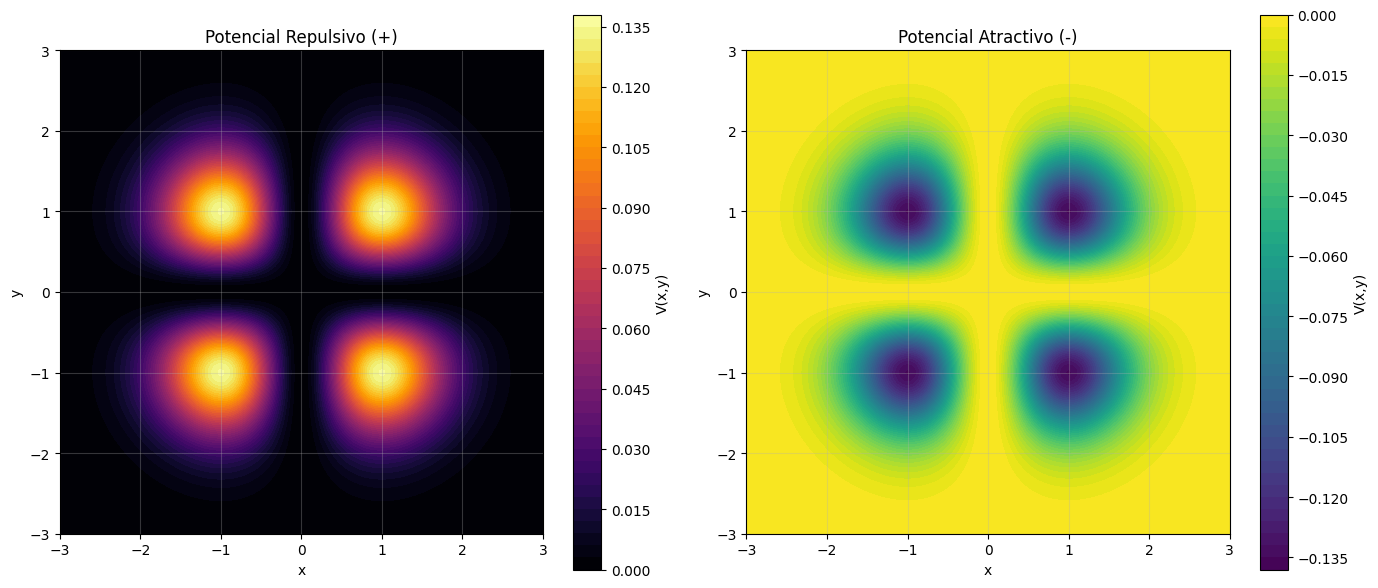

In [2]:
# Definimos el rango de visión
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)

# Creamos la malla 2D
X, Y = np.meshgrid(x, y)

# Definimos la función del potencial
def V(X, Y, signo=1):
    return signo * (X**2) * (Y**2) * np.exp(-(X**2 + Y**2))

# Calculamos ambos casos
V_pos = V(X, Y, signo=1)
V_neg = V(X, Y, signo=-1)

# 3. Graficamos los mapas de calor (Heatmaps)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica para el signo Positivo (Repulsivo)
mapa1 = ax1.contourf(X, Y, V_pos, levels=50, cmap='inferno')
fig.colorbar(mapa1, ax=ax1, label='V(x,y)')
ax1.set_title("Potencial Repulsivo (+)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(alpha=0.3)
ax1.set_aspect('equal')

# Gráfica para el signo Negativo (Atractivo)
mapa2 = ax2.contourf(X, Y, V_neg, levels=50, cmap='viridis')
fig.colorbar(mapa2, ax=ax2, label='V(x,y)')
ax2.set_title("Potencial Atractivo (-)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

+ Identifique visualmente la localización de los máximos.

Visualmente, se observan cuatro picos (en el caso positivo) ubicados de forma simétrica en los cuatro cuadrantes. Si observamos los ejes, los centros de estos picos se ubican aproximadamente en las coordenadas $(1, 1)$, $(-1, 1)$, $(-1, -1)$ y $(1, -1)$. 

+ Describa cómo cambia la forma del potencial al considerar el signo positivo y negativo.

    * Al usar el signo positivo, el potencial actúa como "cuatro montañas" o barreras repulsivas. Si una partícula se acerca al origen, será repelida por estos picos.

    * Al usar el signo negativo, el gráfico se invierte, creando "cuatro pozos" profundos. En este caso, el potencial es atractivo y la partícula tenderá a caer o ser capturada por estos sumideros.


### (b) Demuestre que las ecuaciones de movimiento simultáneas son:

$$m\frac{d^2x}{dt^2} = \mp 2y^2x (1 - x^2) e^{-(x^2+y^2)}$$

$$m\frac{d^2y}{dt^2} = \mp 2x^2y (1 - y^2) e^{-(x^2+y^2)}$$

Sabemos por mecánica clásica que la fuerza ejercida sobre una partícula en un campo conservativo es el gradiente negativo del potencial: $\vec{F} = -\nabla V$. 
Además, por la Segunda Ley de Newton: $\vec{F} = m\vec{a}$. 
Igualando ambas expresiones por componentes, obtenemos:

$$m\frac{d^2x}{dt^2} = -\frac{\partial V}{\partial x}$$
$$m\frac{d^2y}{dt^2} = -\frac{\partial V}{\partial y}$$

Dado el potencial $V(x,y) = \pm x^2 y^2 e^{-(x^2+y^2)}$, procedemos a calcular las derivadas parciales usando la regla del producto y de la cadena.

**1. Para el eje x:**
Mantenemos $y$ constante y derivamos respecto a $x$:
$$\frac{\partial V}{\partial x} = \pm y^2 \left[ \left( \frac{\partial}{\partial x} x^2 \right) e^{-(x^2+y^2)} + x^2 \left( \frac{\partial}{\partial x} e^{-(x^2+y^2)} \right) \right]$$
$$\frac{\partial V}{\partial x} = \pm y^2 \left[ 2x e^{-(x^2+y^2)} + x^2 (-2x) e^{-(x^2+y^2)} \right]$$

Factorizando $2x e^{-(x^2+y^2)}$:
$$\frac{\partial V}{\partial x} = \pm 2xy^2 (1 - x^2) e^{-(x^2+y^2)}$$

Sustituyendo en la ecuación de fuerza (y recordando aplicar el signo negativo que invierte el $\pm$ a $\mp$):
$$m\frac{d^2x}{dt^2} = \mp 2y^2x (1 - x^2) e^{-(x^2+y^2)}$$

**2. Para el eje y:**
Dado que la función del potencial es completamente simétrica respecto a $x$ e $y$, el procedimiento es análogo derivando respecto a $y$ y manteniendo $x$ constante:
$$\frac{\partial V}{\partial y} = \pm 2x^2y (1 - y^2) e^{-(x^2+y^2)}$$

Aplicando el negativo del gradiente obtenemos la segunda ecuación:
$$m\frac{d^2y}{dt^2} = \mp 2x^2y (1 - y^2) e^{-(x^2+y^2)}$$

Quedando así demostradas ambas ecuaciones de movimiento.

### (c) Puntos donde se anula la fuerza y valor máximo del potencial

A partir del literal (b), sabemos que las componentes de la fuerza están dadas por:
$$F_x = \mp 2y^2x(1 - x^2)e^{-(x^2+y^2)}$$
$$F_y = \mp 2x^2y(1 - y^2)e^{-(x^2+y^2)}$$

**1. Demostración de fuerza nula en $x=\pm 1$ y $y=\pm 1$:**
Evaluamos la componente $F_x$ para cualquier valor de $y$, cuando $x = 1$ o $x = -1$.
Notemos el término $(1 - x^2)$ en la ecuación. 
Si evaluamos $x = \pm 1$, entonces $x^2 = (\pm 1)^2 = 1$. 
Por lo tanto, el factor $(1 - x^2) = (1 - 1) = 0$. 
Al multiplicar esto por el resto de la expresión, obtenemos de inmediato:
$$F_x = 0$$

De manera análoga, evaluamos la componente $F_y$ para cualquier valor de $x$, cuando $y = \pm 1$.
El término $(1 - y^2)$ se evaluará como $(1 - (\pm 1)^2) = 1 - 1 = 0$.
En consecuencia:
$$F_y = 0$$

Como ambas componentes de la fuerza son cero en las coordenadas $(x,y) = (\pm 1, \pm 1)$, queda demostrado que la fuerza neta se anula en esos cuatro puntos (puntos de equilibrio).

**2. Valor del potencial en esos puntos:**
Ahora sustituimos $x = \pm 1$ y $y = \pm 1$ en la función original del potencial:
$$V(x,y) = \pm x^2 y^2 e^{-(x^2+y^2)}$$
$$V(\pm 1, \pm 1) = \pm (\pm 1)^2 (\pm 1)^2 e^{- ((\pm 1)^2 + (\pm 1)^2)}$$
$$V(\pm 1, \pm 1) = \pm (1)(1) e^{-(1 + 1)}$$
$$V_{max} = \pm e^{-2}$$

Este resultado establece la escala de energía del problema, ya que es la altura máxima (o profundidad máxima) de nuestro potencial bidimensional.

### (d) Aplique el método de Runge-Kutta de cuarto orden (RK4) para resolver las ecuaciones diferenciales ordinarias de segundo orden.


In [3]:
# Definimos la función de derivadas para aplicarles el método RK4
def potencial_dispersiones(signo, m=0.5):
    """
    signo = 1 (Potencial Repulsivo), signo = -1 (Potencial Atractivo)
    """
    def derivadas(t, state):
        # Desempaquetamos el estado actual
        x, y, vx, vy = state
        
        # Calculamos el factor exponencial
        exp_term = np.exp(-(x**2 + y**2))
        
        # 1 y 2: Derivadas de la posición
        dxdt = vx
        dydt = vy
        
        # 3 y 4: Derivadas de la velocidad (Aceleraciones = Fuerza / m)
        # Nota: El signo de la fuerza es inverso al del potencial (por el gradiente negativo)
        fuerza_x = -signo * 2 * (y**2) * x * (1 - x**2) * exp_term
        fuerza_y = -signo * 2 * (x**2) * y * (1 - y**2) * exp_term
        
        dvxdt = fuerza_x / m
        dvydt = fuerza_y / m
        
        return np.array([dxdt, dydt, dvxdt, dvydt], float)
    
    return derivadas

### (e), (f), (g) Definición de condiciones iniciales, parámetros físicos e implementación

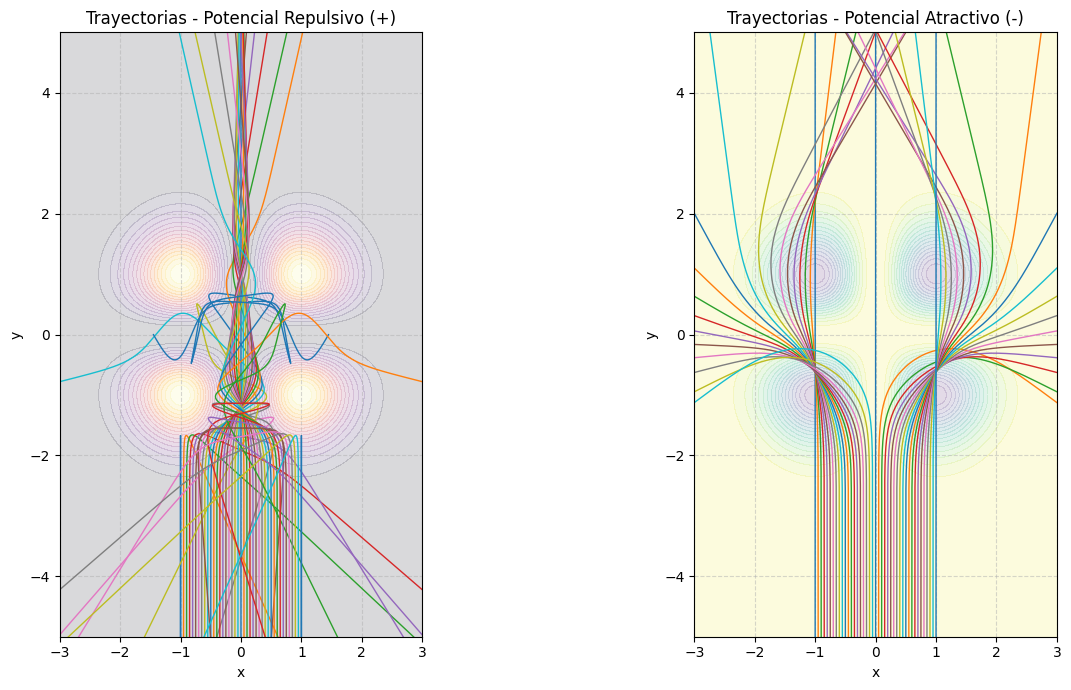

In [4]:
# Parámetros físicos e iniciales (Literales e y f)
m = 0.5
v0y = 0.5
v0x = 0.0
y0 = -5.0  # Posición inicial lejana para que PE/KE < 10^-6
b_array = np.arange(-1.0, 1.01, 0.05)  # Parámetros de impacto de -1 a 1 en pasos de 0.15

# Parámetros de la simulación (Tiempo)
t0 = 0.0
tf = 30.0  
N = 3000
h = (tf - t0) / N
tpoints = np.linspace(t0, tf, N)

# Preparamos las figuras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Bucle para simular ambos potenciales
# signo=1 (Repulsivo), signo=-1 (Atractivo)
for signo, ax, titulo in zip([1, -1], [ax1, ax2], ["Repulsivo (+)", "Atractivo (-)"]):
    
    # Obtenemos la función de derivadas que definimos en el literal d
    derivadas = potencial_dispersiones(signo, m)
    
    # Dibujamos el mapa del potencial de fondo
    x_bg = np.linspace(-3, 3, 200)
    y_bg = np.linspace(-5, 5, 200)
    X, Y = np.meshgrid(x_bg, y_bg)
    V = signo * (X**2) * (Y**2) * np.exp(-(X**2 + Y**2))
    ax.contourf(X, Y, V, levels=20, cmap='inferno' if signo==1 else 'viridis', alpha=0.15)
    
    # Bucle para cada parámetro de impacto b
    for b in b_array:
        # Estado inicial: [x, y, vx, vy]
        state = np.array([b, y0, v0x, v0y], float)
        
        x_traj = np.zeros(N)
        y_traj = np.zeros(N)
        
        # Método RK4 para evolucionar la trayectoria
        for i in range(N):
            x_traj[i] = state[0]
            y_traj[i] = state[1]
            # Usamos la función rk4 de la libreria fcl1109
            state = fc.rk4(derivadas, tpoints[i], state, h)
            
        # Graficamos la trayectoria de este 'b'
        ax.plot(x_traj, y_traj, linewidth=1.0)
        
    ax.set_title(f"Trayectorias - Potencial {titulo}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

+ En el Potencial Repulsivo (+): Las trayectorias son relativamente suaves. Las partículas se acercan, sienten la fuerza de las "montañas" (picos) y se desvían. Algunas quedan parcialmentre atrapadas dentro de las montañas de potencial.

+ En el Potencial Atractivo (-): Algunas trayectorias sufren desviaciones suaves, pero otras (las que entran muy cerca de los pozos de potencial) son temporalmente "capturadas" y orbitan internamente antes de ser escupidas en ángulos completamente aleatorios o caóticos. Esto evidencia que una diferencia diminuta en el parámetro de impacto $b$ produce una trayectoria de salida no relacionada, causando los saltos discontinuos en el ángulo de dispersión.

Para observar mejor el comportamiento de las trayectorias modificamos el parámetro de impacto b y lo hacemos más grande

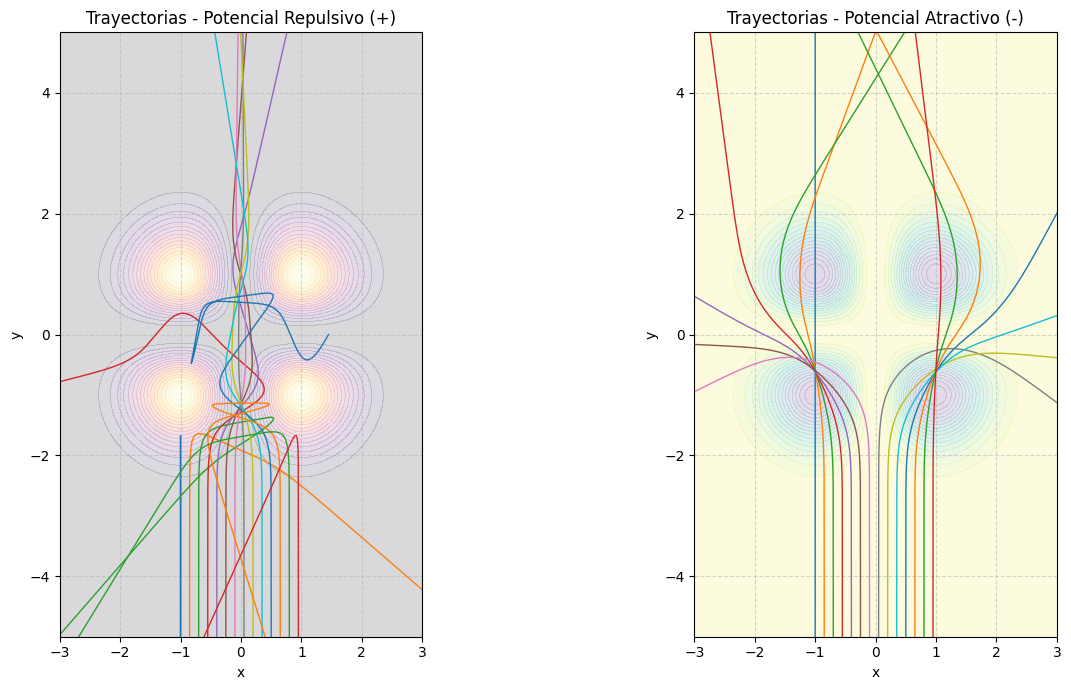

In [5]:
# Parámetros físicos e iniciales (Literales e y f)
m = 0.5
v0y = 0.5
v0x = 0.0
y0 = -5.0  # Posición inicial lejana para que PE/KE < 10^-6
b_array = np.arange(-1.0, 1.01, 0.15)  # Parámetros de impacto de -1 a 1 en pasos de 0.15

# Parámetros de la simulación (Tiempo)
t0 = 0.0
tf = 30.0  
N = 3000
h = (tf - t0) / N
tpoints = np.linspace(t0, tf, N)

# Preparamos las figuras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Bucle para simular ambos potenciales
# signo=1 (Repulsivo), signo=-1 (Atractivo)
for signo, ax, titulo in zip([1, -1], [ax1, ax2], ["Repulsivo (+)", "Atractivo (-)"]):
    
    # Obtenemos la función de derivadas que definimos en el literal d
    derivadas = potencial_dispersiones(signo, m)
    
    # Dibujamos el mapa del potencial de fondo
    x_bg = np.linspace(-3, 3, 200)
    y_bg = np.linspace(-5, 5, 200)
    X, Y = np.meshgrid(x_bg, y_bg)
    V = signo * (X**2) * (Y**2) * np.exp(-(X**2 + Y**2))
    ax.contourf(X, Y, V, levels=20, cmap='inferno' if signo==1 else 'viridis', alpha=0.15)
    
    # Bucle para cada parámetro de impacto b
    for b in b_array:
        # Estado inicial: [x, y, vx, vy]
        state = np.array([b, y0, v0x, v0y], float)
        
        x_traj = np.zeros(N)
        y_traj = np.zeros(N)
        
        # Método RK4 para evolucionar la trayectoria
        for i in range(N):
            x_traj[i] = state[0]
            y_traj[i] = state[1]
            # Usamos la función rk4 de la libreria fcl1109
            state = fc.rk4(derivadas, tpoints[i], state, h)
            
        # Graficamos la trayectoria de este 'b'
        ax.plot(x_traj, y_traj, linewidth=1.0)
        
    ax.set_title(f"Trayectorias - Potencial {titulo}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### (h) Espacio de fase

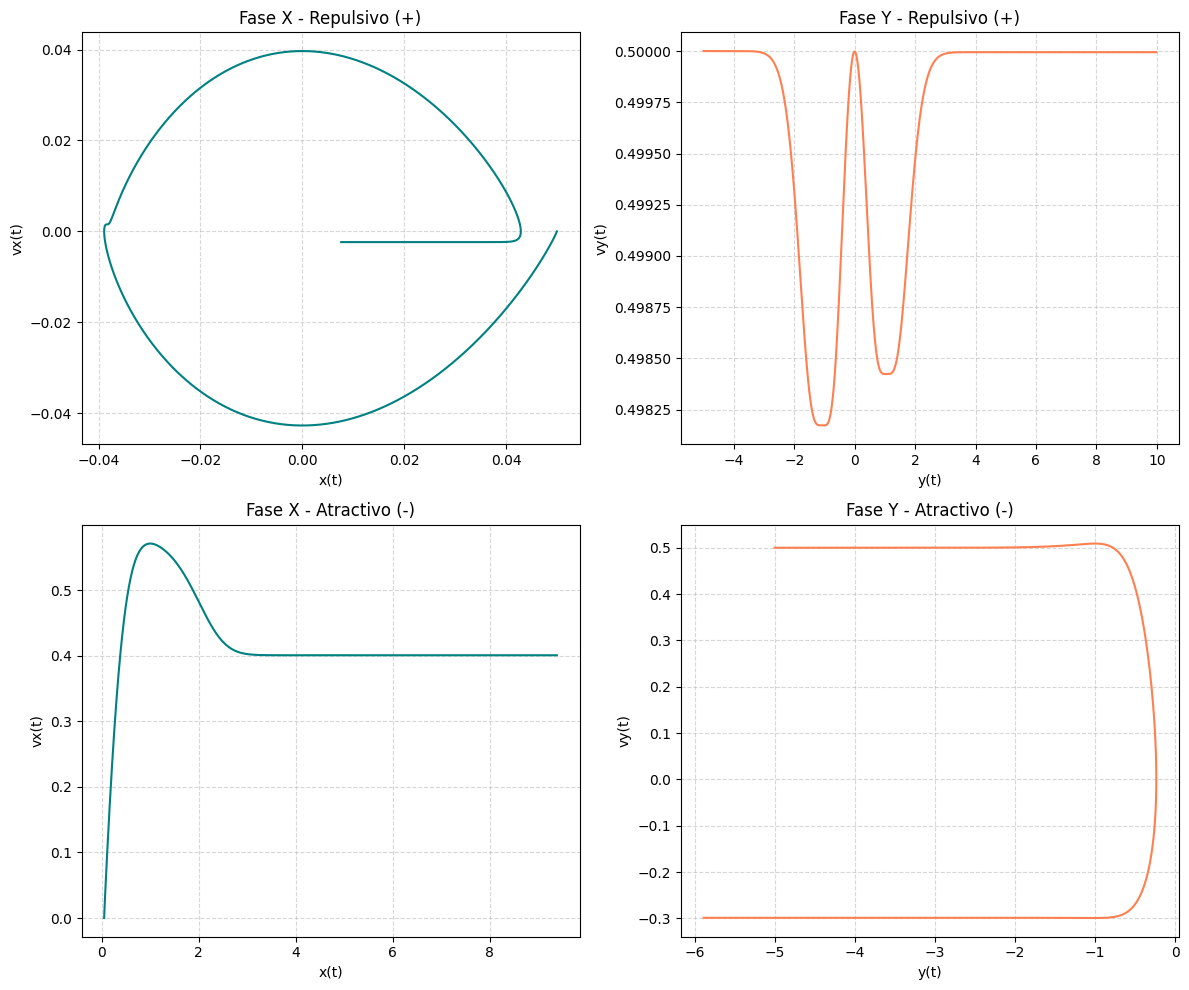

In [6]:
# Parámetros para una trayectoria específica
m = 0.5
v0y = 0.5
v0x = 0.0
y0 = -5.0
b_interesante = 0.05  # Elegimos un b que cause múltiples rebotes internos

t0, tf, N = 0.0, 30.0, 3000
h = (tf - t0) / N
tpoints = np.linspace(t0, tf, N)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Bucle para simular y extraer velocidades
for idx, (signo, titulo) in enumerate(zip([1, -1], ["Repulsivo (+)", "Atractivo (-)"])):
    derivadas = potencial_dispersiones(signo, m)
    
    # Estado inicial: [x, y, vx, vy]
    state = np.array([b_interesante, y0, v0x, v0y], float)
    
    # Ahora guardamos también las velocidades
    x_traj, y_traj = np.zeros(N), np.zeros(N)
    vx_traj, vy_traj = np.zeros(N), np.zeros(N)
    
    for i in range(N):
        x_traj[i], y_traj[i] = state[0], state[1]
        vx_traj[i], vy_traj[i] = state[2], state[3]
        state = fc.rk4(derivadas, tpoints[i], state, h)
        
    # Gráficas del espacio de fases
    # Fase X
    axs[idx, 0].plot(x_traj, vx_traj, color='teal')
    axs[idx, 0].set_title(f"Fase X - {titulo}")
    axs[idx, 0].set_xlabel("x(t)")
    axs[idx, 0].set_ylabel("vx(t)")
    axs[idx, 0].grid(True, linestyle='--', alpha=0.5)
    
    # Fase Y
    axs[idx, 1].plot(y_traj, vy_traj, color='coral')
    axs[idx, 1].set_title(f"Fase Y - {titulo}")
    axs[idx, 1].set_xlabel("y(t)")
    axs[idx, 1].set_ylabel("vy(t)")
    axs[idx, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

+ Estados Ligados: Un estado ligado (como un péndulo o un planeta orbitando una estrella) está confinado en el espacio. En el espacio de fases, sus trayectorias forman curvas cerradas (lazos, elipses o círculos), lo que indica un movimiento periódico donde la partícula vuelve repetidamente a las mismas posiciones con las mismas velocidades.

+ Nuestras trayectorias (Dispersión): Las partículas de este problema vienen del infinito, interactúan con el potencial y vuelven a escapar hacia el infinito. Por lo tanto, en el espacio de fases, forman curvas abiertas. Empiezan en un punto asintótico (con posición lejana y velocidad constante), sufren rizos o variaciones drásticas en la región central de interacción (los picos y valles en la gráfica), pero eventualmente las líneas escapan hacia fuera del gráfico sin cerrarse sobre sí mismas.

### (i) Ángulo de dispersión

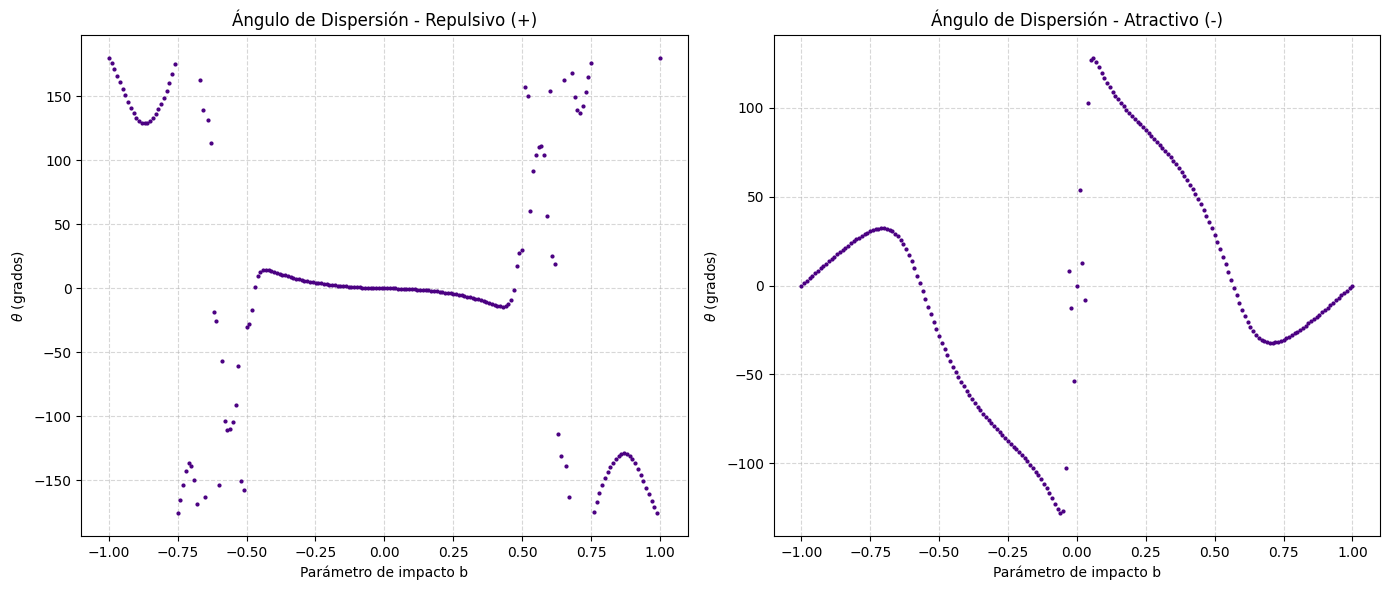

In [7]:
m = 0.5
v0y = 0.5
v0x = 0.0
y0 = -5.0

# Volvemos a un paso muy fino para detectar las discontinuidades
b_array = np.arange(-1.0, 1.001, 0.01) 

t0, tf, N = 0.0, 30.0, 3000
h = (tf - t0) / N
tpoints = np.linspace(t0, tf, N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, signo, titulo in zip([ax1, ax2], [1, -1], ["Repulsivo (+)", "Atractivo (-)"]):
    derivadas = potencial_dispersiones(signo, m)
    theta_finales = []
    
    for b in b_array:
        state = np.array([b, y0, v0x, v0y], float)
        
        # Evolucionamos la trayectoria
        for i in range(N):
            state = fc.rk4(derivadas, tpoints[i], state, h)
            
        # Extraemos el estado final en t = 30
        x_f, y_f, vx_f, vy_f = state
        
        # Verificación física: Asegurarnos de que PE/KE <= 10^-6
        KE = 0.5 * m * (vx_f**2 + vy_f**2)
        PE = np.abs(signo * (x_f**2) * (y_f**2) * np.exp(-(x_f**2 + y_f**2)))
        
        # Calculamos el ángulo en grados para que sea más fácil de interpretar
        theta_rad = np.arctan2(vx_f, vy_f)
        theta_grados = np.degrees(theta_rad)
        theta_finales.append(theta_grados)
        
    # Usamos puntos '.' en lugar de líneas para no unir saltos discontinuos
    ax.plot(b_array, theta_finales, '.', markersize=4, color='indigo')
    ax.set_title(f"Ángulo de Dispersión - {titulo}")
    ax.set_xlabel("Parámetro de impacto b")
    ax.set_ylabel(r"$\theta$ (grados)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### (j) Discontinuidades en el ángulo de dispersión y la sección eficaz

Al observar las gráficas obtenidas en el literal (i), notamos una clara diferencia, siendo el potencial repulsivo el que exhibe el comportamiento complejo:

* **Potencial Repulsivo:** Presenta una "nube" de puntos y discontinuidades severas en ciertas franjas del parámetro de impacto (ej. alrededor de $b \approx \pm 0.8$). (Nota: Los saltos de $\pm 180^\circ$ son artefactos de la función atan2, pero la dispersión de puntos aledaña es caos real).
* **Potencial Atractivo:** La curva es continua (salvo por el cambio de signo natural en el origen). Las partículas simplemente son aceleradas y desviadas por los pozos en un proceso de dispersión suave.

**¿Qué características de las trayectorias causan esto?**
El caos en el potencial repulsivo se debe a las "múltiples dispersiones internas". Al tener una energía cinética ($KE = 0.0625$) menor que la altura de las montañas ($V_{max} \approx 0.135$), la partícula no puede cruzar por encima. Si entra con un parámetro de impacto específico, queda acorralada en el "valle central" en forma de cruz, rebotando repetidamente contra las paredes internas de los 4 picos repulsivos (como en una máquina de pinball) antes de lograr escapar. Esta altísima sensibilidad a las condiciones iniciales rompe la continuidad del ángulo de salida.

**Efecto en la sección eficaz $\sigma(\theta)$:**
La sección eficaz diferencial es proporcional a $\left| \frac{db}{d\theta} \right|$. En la región caótica del potencial repulsivo, la derivada $\frac{d\theta}{db}$ oscila violentamente y tiende a infinito en múltiples puntos. Esto causa singularidades en la sección eficaz, lo que significa que a un mismo ángulo final $\theta$ llegan partículas que entraron con parámetros de impacto completamente distintos, haciendo que la predicción analítica tradicional falle en esa región.

### (k) Comparación de trayectorias con energías menores y mayores a $V_{max}$

V_max (Barrera del Potencial) = 0.1353
Energía Cinética Inicial (KE) = 0.2500
¿KE > V_max? -> True


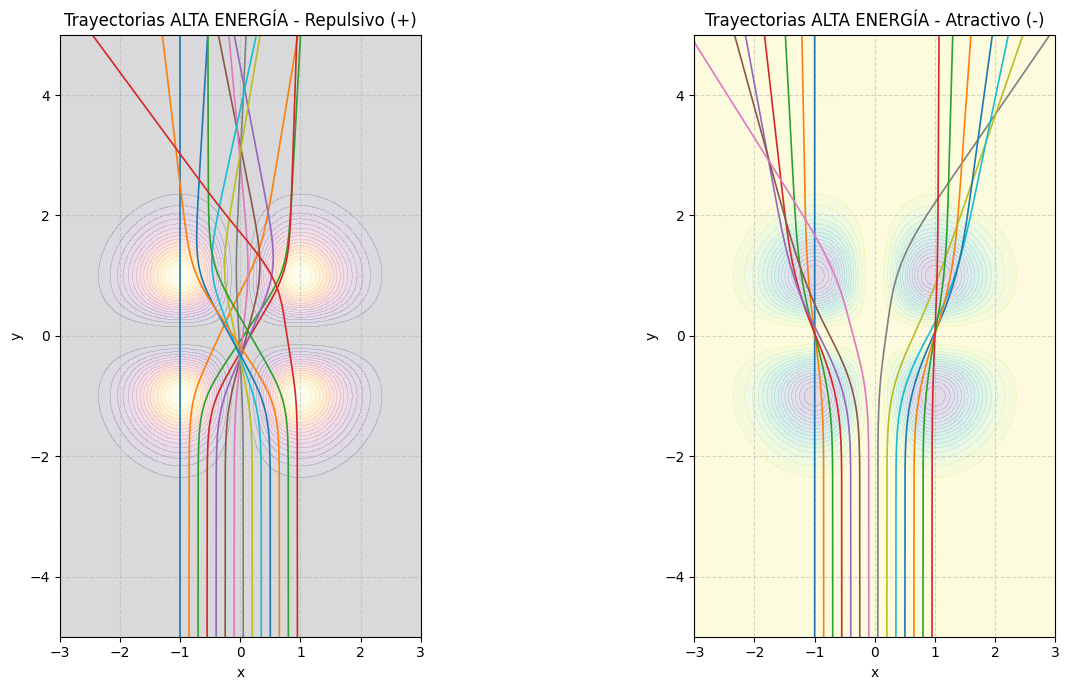

In [8]:
# --- Parámetros de ALTA energía ---
m = 0.5
v0y_alta = 1.0  # Incrementamos la velocidad para romper la barrera
v0x = 0.0
y0 = -5.0
b_array = np.arange(-1.0, 1.01, 0.15) 

# Verificación de energías
KE_alta = 0.5 * m * (v0y_alta**2)
V_max = np.exp(-2)
print(f"V_max (Barrera del Potencial) = {V_max:.4f}")
print(f"Energía Cinética Inicial (KE) = {KE_alta:.4f}")
print(f"¿KE > V_max? -> {KE_alta > V_max}")

t0, tf, N = 0.0, 30.0, 3000
h = (tf - t0) / N
tpoints = np.linspace(t0, tf, N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

for signo, ax, titulo in zip([1, -1], [ax1, ax2], ["Repulsivo (+)", "Atractivo (-)"]):
    derivadas = potencial_dispersiones(signo, m)
    
    # Dibujamos el mapa del potencial de fondo
    x_bg = np.linspace(-3, 3, 200)
    y_bg = np.linspace(-5, 5, 200)
    X, Y = np.meshgrid(x_bg, y_bg)
    V = signo * (X**2) * (Y**2) * np.exp(-(X**2 + Y**2))
    ax.contourf(X, Y, V, levels=20, cmap='inferno' if signo==1 else 'viridis', alpha=0.15)
    
    for b in b_array:
        state = np.array([b, y0, v0x, v0y_alta], float)
        x_traj = np.zeros(N)
        y_traj = np.zeros(N)
        
        for i in range(N):
            x_traj[i], y_traj[i] = state[0], state[1]
            state = fc.rk4(derivadas, tpoints[i], state, h)
            
        ax.plot(x_traj, y_traj, linewidth=1.2)
        
    ax.set_title(f"Trayectorias ALTA ENERGÍA - {titulo}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

La altura máxima del potencial (o profundidad del pozo) es $V_{max} = e^{-2} \approx 0.135$. 

1. **Régimen de Baja Energía ($KE < V_{max}$):**
   *(Este es el caso analizado en los literales anteriores con $v_y = 0.5$ y $KE = 0.0625$).*
   * **Potencial Repulsivo:** Las partículas no tienen suficiente energía para superar las "montañas" del potencial. Se reflejan fuertemente, rebotando hacia atrás o hacia los lados en grandes ángulos.
   * **Potencial Atractivo:** Las partículas son capturadas fácilmente. Al viajar lento, el pozo tiene suficiente tiempo para curvar su trayectoria drásticamente, produciendo el comportamiento caótico y las discontinuidades.

2. **Régimen de Alta Energía ($KE > V_{max}$):**
   *(Caso actual con $v_y = 1.0$ y $KE = 0.25$).*
   * **Potencial Repulsivo:** La partícula tiene tanta energía cinética que la barrera repulsiva se vuelve casi insignificante. Las partículas "atraviesan" las montañas por la fuerza, sufriendo únicamente desviaciones muy leves. 
   * **Potencial Atractivo:** Al moverse a gran velocidad, la partícula pasa tan rápido por la región de los pozos atractivos que el pozo apenas tiene tiempo de alterar su trayectoria. No ocurren capturas temporales y el comportamiento caótico o discontinuo desaparece casi por completo. La dispersión vuelve a ser un proceso continuo y suave.

### (l) Retardo temporal $T(b)$ y su relación con el comportamiento inusual

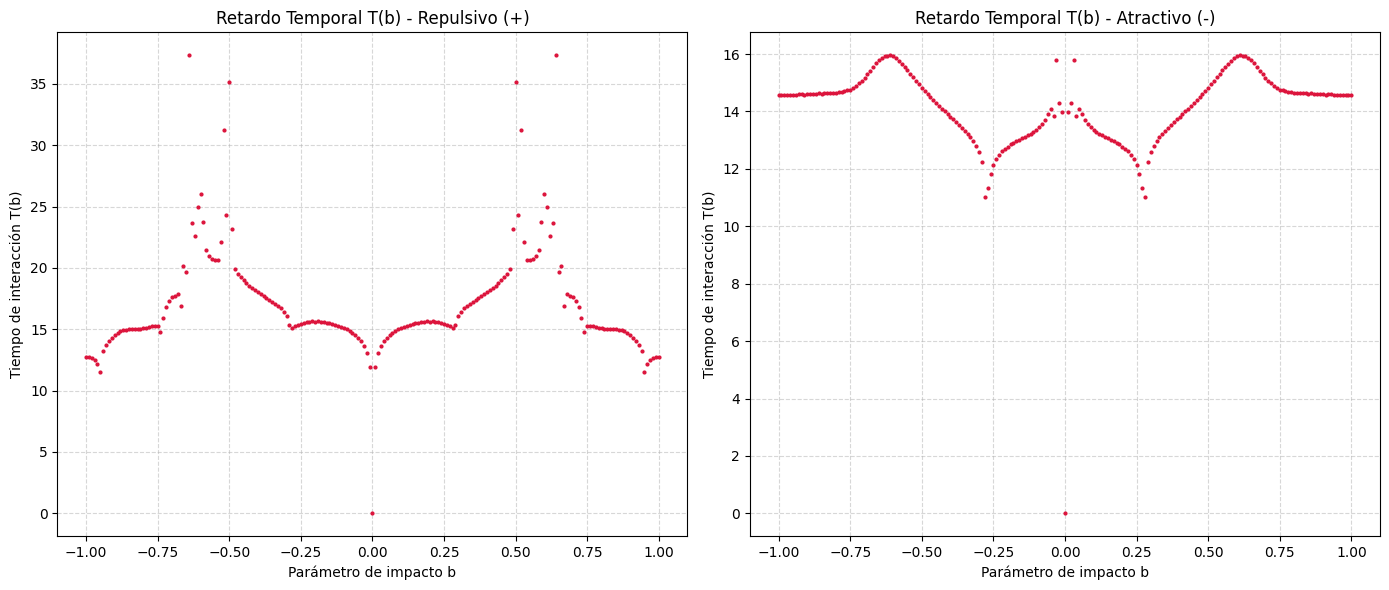

In [9]:
# --- Parámetros iniciales (Volvemos a baja energía para ver las capturas) ---
m = 0.5
v0y = 0.5
v0x = 0.0
y0 = -5.0
b_array = np.arange(-1.0, 1.001, 0.01) 

# Aumentamos tf para permitir que las órbitas largas terminen
t0, tf, N = 0.0, 50.0, 5000 
h = (tf - t0) / N
tpoints = np.linspace(t0, tf, N)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, signo, titulo in zip([ax1, ax2], [1, -1], ["Repulsivo (+)", "Atractivo (-)"]):
    derivadas = potencial_dispersiones(signo, m)
    T_retardo = []
    
    for b in b_array:
        state = np.array([b, y0, v0x, v0y], float)
        tiempo_interaccion = 0.0
        
        # Evolucionamos la trayectoria
        for i in range(N):
            x, y, vx, vy = state
            
            # Calculamos energías en este instante
            KE = 0.5 * m * (vx**2 + vy**2)
            PE = np.abs(signo * (x**2) * (y**2) * np.exp(-(x**2 + y**2)))
            
            # Si estamos en la región de interacción fuerte, sumamos este paso de tiempo
            if KE > 0 and (PE / KE) > 1e-6:
                tiempo_interaccion += h
                
            state = fc.rk4(derivadas, tpoints[i], state, h)
            
        T_retardo.append(tiempo_interaccion)
        
    ax.plot(b_array, T_retardo, '.', markersize=4, color='crimson')
    ax.set_title(f"Retardo Temporal T(b) - {titulo}")
    ax.set_xlabel("Parámetro de impacto b")
    ax.set_ylabel("Tiempo de interacción T(b)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### (l) Retardo temporal $T(b)$ y su relación con el comportamiento inusual

Al calcular y graficar el tiempo de interacción $T(b)$ (el tiempo que la partícula pasa en la región donde $PE/KE > 10^{-6}$) para cada parámetro de impacto, observamos dos comportamientos drásticamente distintos que confirman nuestros hallazgos anteriores:

1. **Potencial Repulsivo:** Aparecen picos masivos o "singularidades" en el retardo temporal en las mismas franjas del parámetro de impacto donde observamos el caos en el ángulo de dispersión (ej. $b \approx \pm 0.8$). 
Físicamente, estos picos representan las partículas que entran al valle central y quedan acorraladas, rebotando múltiples veces contra las paredes internas de los 4 picos repulsivos. Cada rebote adicional suma una cantidad enorme de tiempo antes de que la partícula encuentre un ángulo de escape. 
2. **Potencial Atractivo:** La curva de retardo temporal es continua y suave. Al acercarse a los pozos, las partículas aceleran y salen disparadas rápidamente. Aunque el tiempo de interacción varía dependiendo de qué tan cerca pasen del centro, no hay "capturas" prolongadas, lo que coincide con la dispersión continua que vimos en el literal (j).

En los picos más altos, la partícula pasa un tiempo extraordinariamente largo "atrapada" en la región de interacción en comparación con una partícula libre. Esta gráfica de retardo temporal confirma que la dispersión irregular es causada estrictamente por el fenómeno de **múltiples dispersiones internas** (rebotes) dentro de las barreras del potencial repulsivo.